In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/10000
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 11
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  66 0.5250000000000001 0.6500000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  0 , total integrated cost =  13311.435770934964
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  0 , total integrated cost =  21565.177588309605
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  33 0.5000000000000002 0.525000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  1 , total integrated cost =  97.92849587973795
RUN  2 , total integrated cost =  83.85011967904515
RUN  3 , total integrated cost =  64.82982416181909
RUN  4 , total integrated cost =  57.949494556858724
RUN  5 , total integrated cost =  50.603211771957056
RUN  6 , total integrated cost =  46.667112634839576
RUN  7 , total integrated cost =  43.286133678995164
RUN  8 , total integrated cost =  40.129906493202775
RUN  9 , total integrated cost =  37.52410089615495
RUN  10 , total integrated cost =  34.1167305502734
RUN  11 , total integrated cost =  32.97137575421676
RUN  12 , total integrated cost =  32.06356952808008
RUN  13 , total integrated cost =  30.226786422463142
RUN  14 , total integrated cost =  30.1104451249426
RUN  15 , total integrated cost =  29.844592708954508
RUN  

ERROR:root:Problem in initial value trasfer


RUN  80 , total integrated cost =  25.660622569460262
Control only changes marginally.
RUN  80 , total integrated cost =  25.660622569460262
Improved over  80  iterations in  19.387434093281627  seconds by  99.80722873917561  percent.
Problem in initial value trasfer:  Vmean_exc -65.76729084536356 -65.77363018875518
weight =  5187.495250710495
set cost params:  1.0 0.0 5187.495250710495
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13079.445190362669
Gradient descend method:  None
RUN  1 , total integrated cost =  12106.002470319356
RUN  2 , total integrated cost =  12102.887693102726
RUN  3 , total integrated cost =  12102.315598667961
RUN  4 , total integrated cost =  12101.923079526552
RUN  5 , total integrated cost =  12098.589497170358
RUN  6 , total integrated cost =  12097.457685976406
RUN  7 , total integrated cost =  12097.272185537851
RUN  8 , total integrated cost =  12069.214439996093
RUN  9 , total integrated cost =  12065.305815025333
RUN  10 , t

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  12065.298813076859
RUN  14 , total integrated cost =  12065.298813076855
RUN  15 , total integrated cost =  12065.298813076854
RUN  16 , total integrated cost =  12065.298813076854
Control only changes marginally.
RUN  16 , total integrated cost =  12065.298813076854
Improved over  16  iterations in  0.6137637831270695  seconds by  7.75374155803695  percent.
Problem in initial value trasfer:  Vmean_exc -58.592113554221186 -58.59676256436606
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  1 , total integrated cost =  148.25131723681145
RUN  2 , total integrated cost =  121.78883124473087
RUN  3 , total integrated cost =  88.2377133084613
RUN  4 , total integrated cost =  78.13478512258807
RUN  5 , total integrated cost =  69.0877691979976
RUN  6 , total integrated cost =  64.07327778707855
RUN  

...

RUN  19 , total integrated cost =  9541.928499714395
RUN  20 , total integrated cost =  9541.928499714386
Control only changes marginally.
RUN  21 , total integrated cost =  9541.928499714386
Improved over  21  iterations in  0.8163345642387867  seconds by  4.849378875575795  percent.
Problem in initial value trasfer:  Vmean_exc -61.97750360534305 -62.02722278384981
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23430.768838654094
Gradient descend method:  None
RUN  1 , total integrated cost =  157.56555897013087
RUN  2 , total integrated cost =  125.82044972307857
RUN  3 , total integrated cost =  92.14659995385904
RUN  4 , total integrated cost =  81.88396960269587
RUN  5 , total integrated cost =  72.45124341964708
RUN  6 , total integrated cost =  67.07174326391707
RUN  7 , total integrated cost =  62.658175201901464
RUN  8 , total integrated cost =  58.84833982555737
RUN  9 ,

ERROR:root:Problem in initial value trasfer


RUN  80 , total integrated cost =  42.5481550153494
Control only changes marginally.
RUN  83 , total integrated cost =  42.54815501534935
Improved over  83  iterations in  1.8601924609392881  seconds by  99.81840905303476  percent.
Problem in initial value trasfer:  Vmean_exc -67.08136063671154 -67.11236077667019
weight =  5506.882455937604
set cost params:  1.0 0.0 5506.882455937604
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22843.1348672036
Gradient descend method:  None
RUN  1 , total integrated cost =  20923.57583043594
RUN  2 , total integrated cost =  20912.10676949148
RUN  3 , total integrated cost =  20805.489567004395
RUN  4 , total integrated cost =  20749.733924368793
RUN  5 , total integrated cost =  20718.15909498016
RUN  6 , total integrated cost =  20697.86829764439
RUN  7 , total integrated cost =  20697.810373277807
RUN  8 , total integrated cost =  20697.775885009574
RUN  9 , total integrated cost =  20697.448535273503
RUN  10 , total inte

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  20688.566563291755
State only changes marginally.
Control only changes marginally.
RUN  43 , total integrated cost =  20688.566563291748
Improved over  43  iterations in  1.5022011995315552  seconds by  9.432016736920005  percent.
Problem in initial value trasfer:  Vmean_exc -57.24475607009461 -57.23192576183801


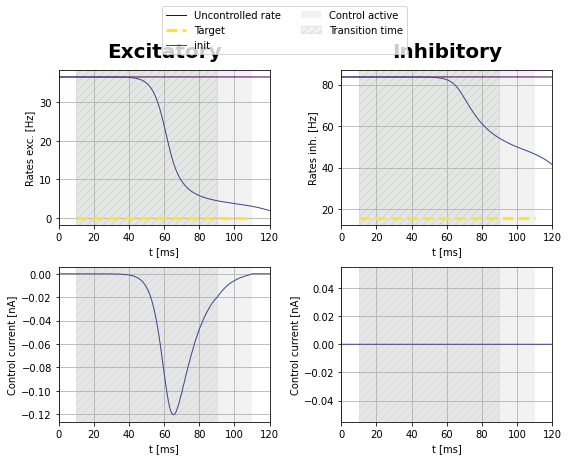

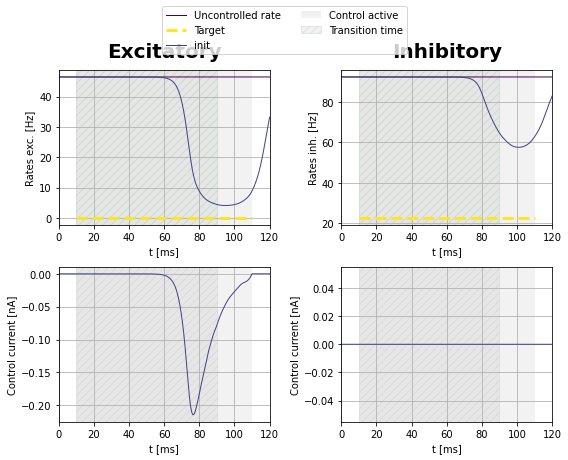

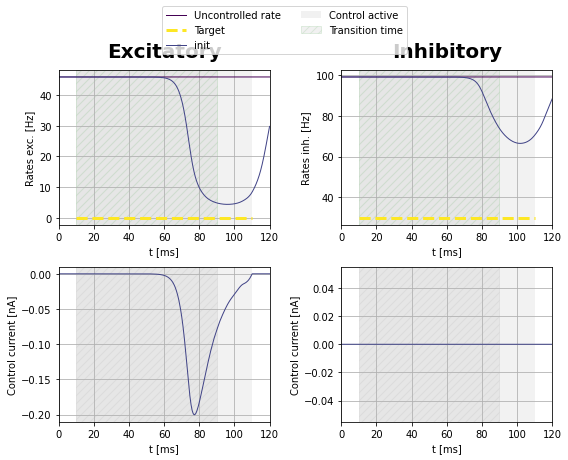

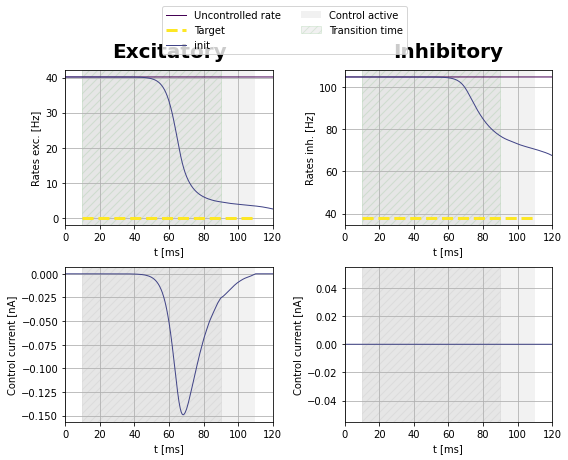

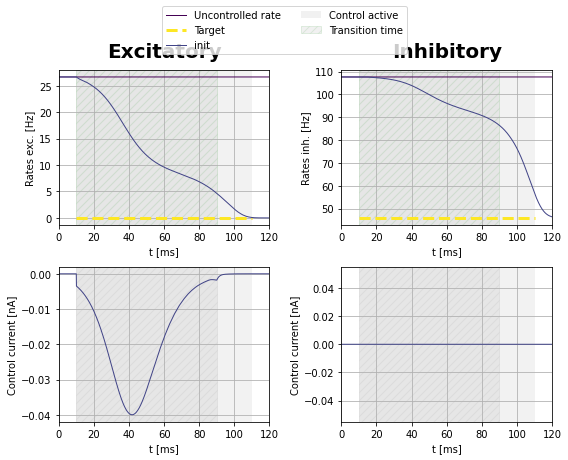

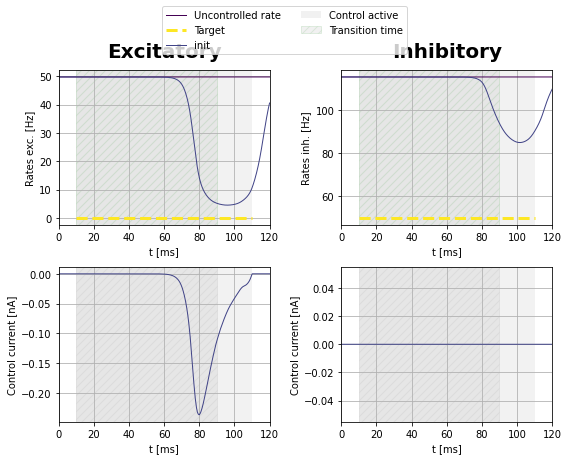

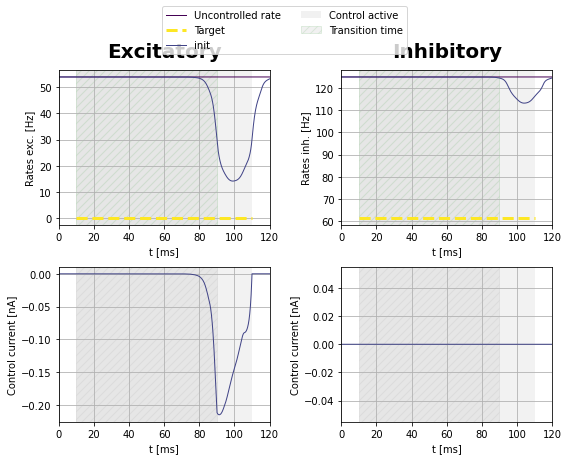

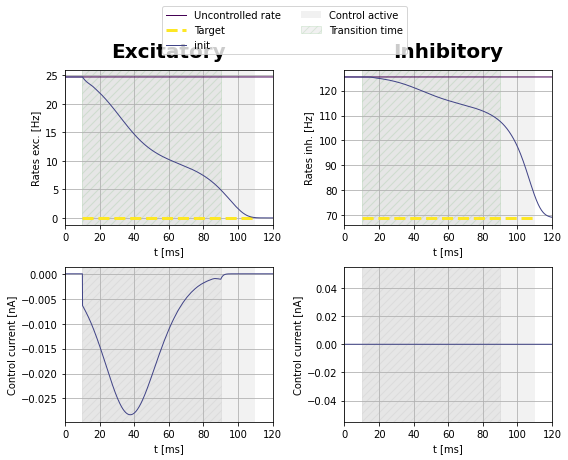

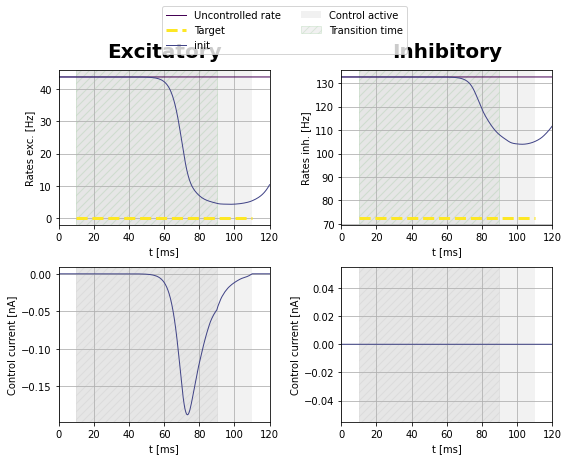

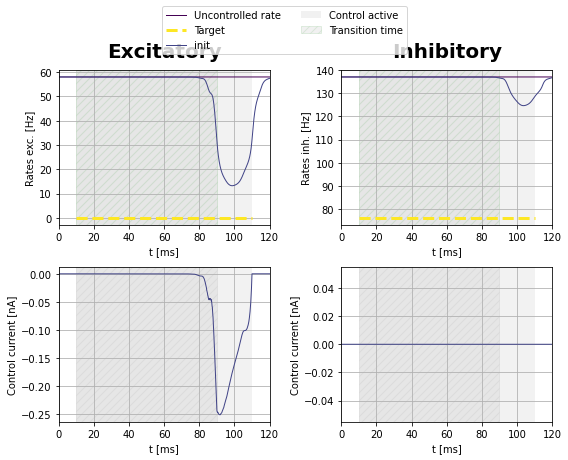

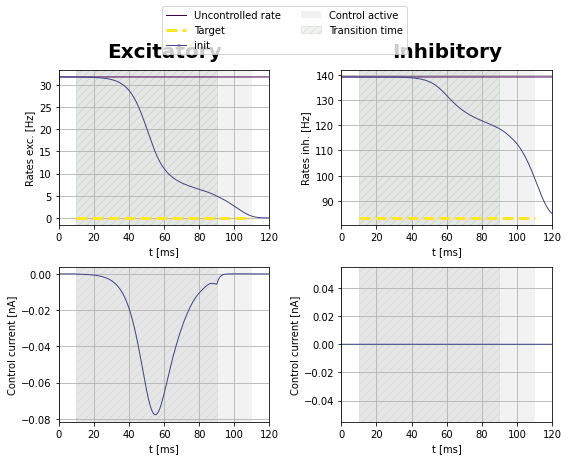

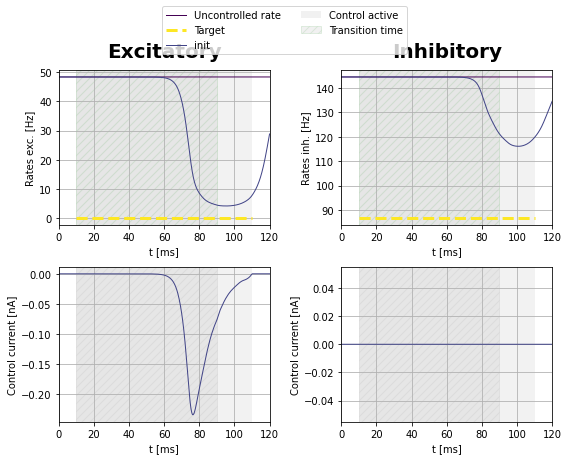

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  11 0.4500000000000001 0.42500000000000016
found solution for  11
-------  22 0.5000000000000002 0.4750000000000002
[0, 11] []
closest index  11
s

ERROR:root:Problem in initial value trasfer


RUN  44 , total integrated cost =  39.9609523552817
Improved over  44  iterations in  1.4376927856355906  seconds by  99.79642764564471  percent.
Problem in initial value trasfer:  Vmean_exc -64.403234078217 -64.41242155855429
weight =  5396.562473431468
set cost params:  1.0 0.0 5396.562473431468
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21124.3022968697
Gradient descend method:  None
RUN  1 , total integrated cost =  19612.07837553698
RUN  2 , total integrated cost =  19608.167300578003
RUN  3 , total integrated cost =  19582.372642549413
RUN  4 , total integrated cost =  19561.71303831002
RUN  5 , total integrated cost =  19554.83051461091
RUN  6 , total integrated cost =  19547.509019363693
RUN  7 , total integrated cost =  19546.62142238434
RUN  8 , total integrated cost =  19540.06153585822
RUN  9 , total integrated cost =  19535.026116674653
RUN  10 , total integrated cost =  19533.98096786855
RUN  11 , total integrated cost =  19531.702188102565
RU

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  19487.041213819415
Control only changes marginally.
RUN  30 , total integrated cost =  19487.041213819415
Improved over  30  iterations in  1.2362162005156279  seconds by  7.750604304185245  percent.
Problem in initial value trasfer:  Vmean_exc -57.3349084471379 -57.32218998591377
-------  33 0.5000000000000002 0.5250000000000002
[0, 11] []
closest index  11
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19081.34052233892
Gradient descend method:  None
RUN  1 , total integrated cost =  109.4651906517895
RUN  2 , total integrated cost =  99.40627082002365
RUN  3 , total integrated cost =  89.57392674311345
RUN  4 , total integrated cost =  84.53334078803458
RUN  5 , total integrated cost =  78.32466186389905
RUN  6 , total integrated cost =  74.92668475082614
RUN  7 , total integrated cost =  70.47750696174784
RUN  8 , total integrated cost =  67.94992471173381
RUN  9 , total

...

Control only changes marginally.
RUN  75 , total integrated cost =  23742.454704614778
Improved over  75  iterations in  3.061507251113653  seconds by  15.667866720308467  percent.
Problem in initial value trasfer:  Vmean_exc -56.65278506642153 -56.65585383599504
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
[0, 11, 44, 55, 77, 99, 110, 132, 33, 66, 143] [110, 132, 99, 77, 66, 55, 143, 44, 33, 11]
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33774.69431319483
Gradient descend method:  None
RUN  1 , total integrated cost =  203.71431427932347
RUN  2 , total integrated cost =  125.49270763004799
RUN  3 , total integrated cost =  65.5474599249269
RUN  4 , total integrated cost =  63.197477654071
RUN  5 , total integrated cost =  62.11523895421249
RUN  6 , total integrated cost =  62.021787

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  54 , total integrated cost =  57.61767000978473
Improved over  54  iterations in  2.141930779442191  seconds by  99.82940579868617  percent.
Problem in initial value trasfer:  Vmean_exc -64.1836429339837 -64.19760745510294
weight =  5837.17774760645
set cost params:  1.0 0.0 5837.17774760645
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  32548.817221655892
Gradient descend method:  None
RUN  1 , total integrated cost =  29699.590260061923
RUN  2 , total integrated cost =  29672.642921823804
RUN  3 , total integrated cost =  29640.80526846969
RUN  4 , total integrated cost =  29611.106810461104
RUN  5 , total integrated cost =  29573.704494949227
RUN  6 , total integrated cost =  29543.01214047798
RUN  7 , total integrated cost =  29491.15869719018
RUN  8 , total integrated cost =  29448.52323728104
RUN  9 , total integrated cost =  29211.23743377953
RUN  10 , total integrated cost =  29190.4539222967
RUN  11 , total integra

ERROR:root:Problem in initial value trasfer


RUN  70 , total integrated cost =  27647.016406192957
Control only changes marginally.
RUN  72 , total integrated cost =  27647.01640619295
Improved over  72  iterations in  2.828981928527355  seconds by  15.059843133720989  percent.
Problem in initial value trasfer:  Vmean_exc -56.656154713651816 -56.65982950111738
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006
------------------------------------------------------------
-------------------- 11
------------------------------------------------------------
found solution:  [0, 11, 44, 55, 77, 99, 110, 132, 33, 66, 143]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
closest index  -1
set cost params:  1.0 0.0 10.0
all options tried already
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  5722.273904084374
set cost params:  1.0 0.0 5722.273904084374
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13294.595084058581
Gradient descend method:  None
RUN  1 , total integrated cost =  13294.01711638291
RUN  2 , total integrated cost =  13294.01540166155
RUN  3 , total integrated cost =  13294.01538046506
RUN  4 , total integrated cost =  13294.015379794855
RUN  5 , total integrated cost =  13294.015379777578
RUN  6 , total integrated cost =  13294.015379776965
RUN  7 , total integrated cost =  13294.015379776944
RUN  8 , total integrated cost =  13294.015379776934


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  13294.015379776934
Control only changes marginally.
RUN  9 , total integrated cost =  13294.015379776934
Improved over  9  iterations in  0.45596581511199474  seconds by  0.004360450829693718  percent.
Problem in initial value trasfer:  Vmean_exc -58.43449281423132 -58.43782705387688
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  5952.488406110398
set cost params:  1.0 0.0 5952.488406110398
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21551.592500402166
Gradient descend method:  None
RUN  1 , total integrated cost =  21551.28897713614
RUN  2 , total integrated cost =  21551.288899373063
RUN  3 , total integrated cost =  21551.288898545343


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  21551.288898540115
RUN  5 , total integrated cost =  21551.28889854011
RUN  6 , total integrated cost =  21551.288898540104
RUN  7 , total integrated cost =  21551.288898540104
Control only changes marginally.
RUN  7 , total integrated cost =  21551.288898540104
Improved over  7  iterations in  0.4205943960696459  seconds by  0.0014087212444167108  percent.
Problem in initial value trasfer:  Vmean_exc -57.637900835719236 -57.625926755292966
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  5990.571344548907
set cost params:  1.0 0.0 5990.571344548907
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21054.899177459414
Gradient descend method:  None
RUN  1 , total integrated cost =  21054.682514669432
RUN  2 , total integrated cost =  21054.68128563974
RUN  3 , total integrated cost =  21054.681271934594
RUN  4 , total integrated cost =  21054.681270492776
RUN  5 , total integrated cost =  21054.68127021660

...

RUN  4 , total integrated cost =  33615.8948977812
Control only changes marginally.
RUN  4 , total integrated cost =  33615.8948977812
Improved over  4  iterations in  0.3465156275779009  seconds by  1.9998485285555034e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.70387254690325 -56.703843215054405
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [False, False], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
--

ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  29112.19778232905
RUN  3 , total integrated cost =  29112.197782329036
RUN  4 , total integrated cost =  29112.197782329036
Control only changes marginally.
RUN  4 , total integrated cost =  29112.197782329036
Improved over  4  iterations in  0.3031932469457388  seconds by  1.3752278064771417e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.70397731779363 -56.70400314421591
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-------  121 0.5750000000000002 0.8250000000000005
no convergence
weight =  8646.159181107114
set cost params:  1.0 0.0 8646.159181107114
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33616.636529092706
Gradient descend method:  None
RUN  1 , total integrated cost =  33616.63045334775
RUN  2 , total integrated cost =  33616.630453347745


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  33616.630453347745
Control only changes marginally.
RUN  3 , total integrated cost =  33616.630453347745
Improved over  3  iterations in  0.2602821234613657  seconds by  1.8073625412284855e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.70386668623152 -56.70383786688442
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143


In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [False, False], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  175.54827930530723
Gradient descend method:  None
RUN  1 , total integrated cost =  25.662638367309604
RUN  2 , total integrated cost =  25.66253991388255
RUN  3 , total integrated cost =  25.661940855069897
RUN  4 , total integrated cost =  25.2978164988635
RUN  5 , total integrated cost =  25.297213163247417
RUN  6 , total integrated cost =  25.29513629137082
RUN  7 , total integrated cost =  25.25317716746535
RUN  8 , total integrated cost =  25.237017391690063
RUN  9 , total integrated cost =  25.23670958716244
RUN  10 , total integrated cost =  25.236592326985917
RUN  11 , total integrated cost =  25.236445641939603
RUN  12 , total integrated cost =  25.235930123779184
RUN  13 , total integrated cost =  25.049052773531205
RUN  14 , total integrated cost =  24.991666209588317
RUN  15 , total integrated cost =  24.990001612338467
R

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  32 , total integrated cost =  24.857562550024475
Improved over  32  iterations in  6.70213820040226  seconds by  85.84004203949326  percent.
Problem in initial value trasfer:  Vmean_exc -65.94013655927395 -65.9449270380516
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  245.77588676063903
Gradient descend method:  HS
RUN  1 , total integrated cost =  241.81193748440782
RUN  2 , total integrated cost =  240.98540963053657
RUN  3 , total integrated cost =  240.85599944472582
RUN  4 , total integrated cost =  240.8559994447257


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  240.8559994447257
Control only changes marginally.
RUN  5 , total integrated cost =  240.8559994447257
Improved over  5  iterations in  1.1796727068722248  seconds by  2.0017778720110186  percent.
Problem in initial value trasfer:  Vmean_exc -64.8005925242166 -64.81747141830621
weight =  5525.719617374455
set cost params:  1.0 0.0 5525.719617374455
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13160.292568030627
Gradient descend method:  None
RUN  1 , total integrated cost =  12832.542111380519
RUN  2 , total integrated cost =  12831.261007025003
RUN  3 , total integrated cost =  12831.203345249567
RUN  4 , total integrated cost =  12830.669516702606
RUN  5 , total integrated cost =  12828.85385409191
RUN  6 , total integrated cost =  12828.678158532362
RUN  7 , total integrated cost =  12828.63676737501
RUN  8 , total integrated cost =  12828.439972128384
RUN  9 , total integrated cost =  12826.755442320644
RUN  10 , total in

...

RUN  8 , total integrated cost =  40.139103439793914
Control only changes marginally.
RUN  8 , total integrated cost =  40.139103439793914
Improved over  8  iterations in  1.5978802014142275  seconds by  75.49330449468192  percent.
Problem in initial value trasfer:  Vmean_exc -68.15859991155662 -68.18509944940904
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  396.7378912037638
Gradient descend method:  HS
RUN  1 , total integrated cost =  390.3053547137279
RUN  2 , total integrated cost =  389.7035248009759
RUN  3 , total integrated cost =  389.6889553285749
RUN  4 , total integrated cost =  389.63011765219545
RUN  5 , total integrated cost =  389.62892583383666
RUN  6 , total integrated cost =  389.62845465486004
RUN  7 , total integrated cost =  389.6284546548598


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  389.6284546548598
Control only changes marginally.
RUN  8 , total integrated cost =  389.6284546548598
Improved over  8  iterations in  1.8981600273400545  seconds by  1.7919731657928821  percent.
Problem in initial value trasfer:  Vmean_exc -65.08100237892768 -65.11701468891488
weight =  6012.618502121338
set cost params:  1.0 0.0 6012.618502121338
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23179.682670812486
Gradient descend method:  None
RUN  1 , total integrated cost =  22697.665883476355
RUN  2 , total integrated cost =  22696.291939566338
RUN  3 , total integrated cost =  22695.84484146439
RUN  4 , total integrated cost =  22694.4849340866
RUN  5 , total integrated cost =  22694.194476349043
RUN  6 , total integrated cost =  22692.389355196014
RUN  7 , total integrated cost =  22689.605629001413
RUN  8 , total integrated cost =  22689.445997209783
RUN  9 , total integrated cost =  22686.519130607117
RUN  10 , total in

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  69 , total integrated cost =  22653.93313735466
Improved over  69  iterations in  16.059688521549106  seconds by  2.268148105926599  percent.
Problem in initial value trasfer:  Vmean_exc -58.07801931290981 -58.071215349473974


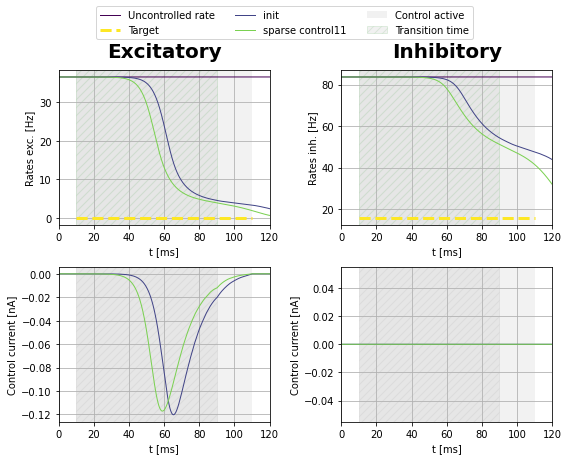

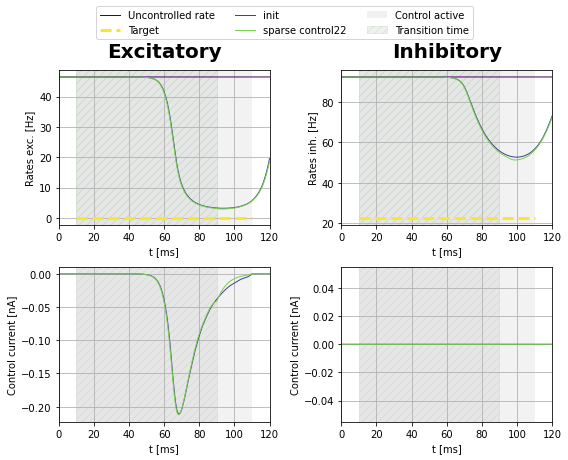

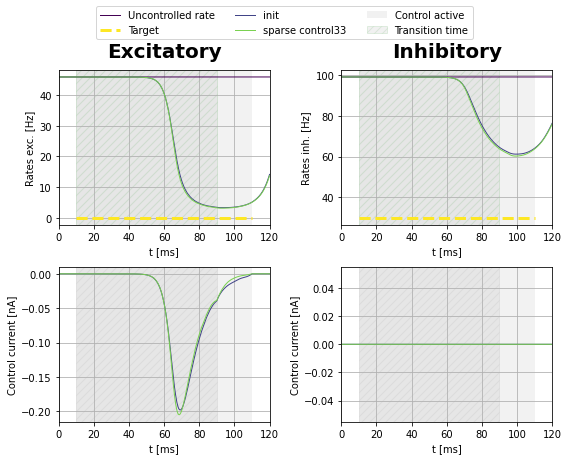

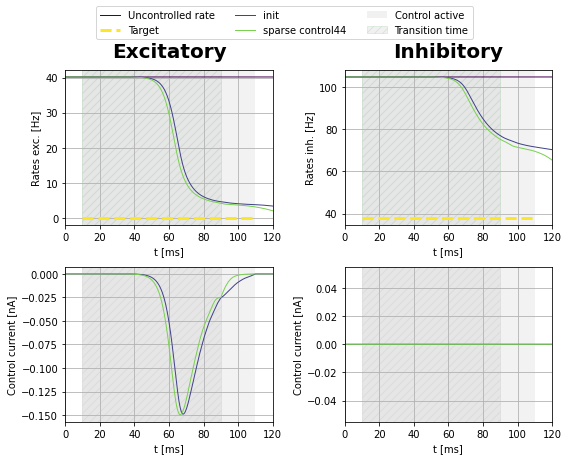

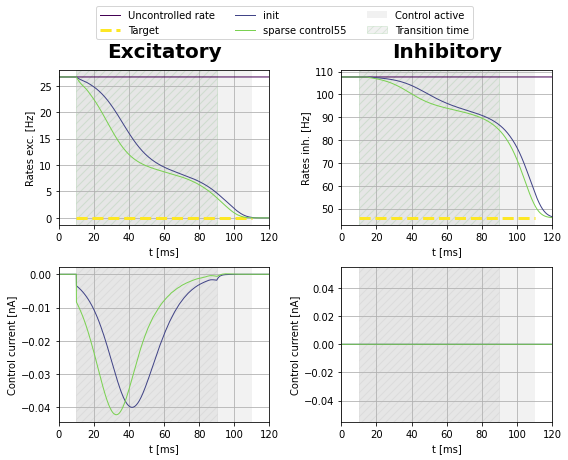

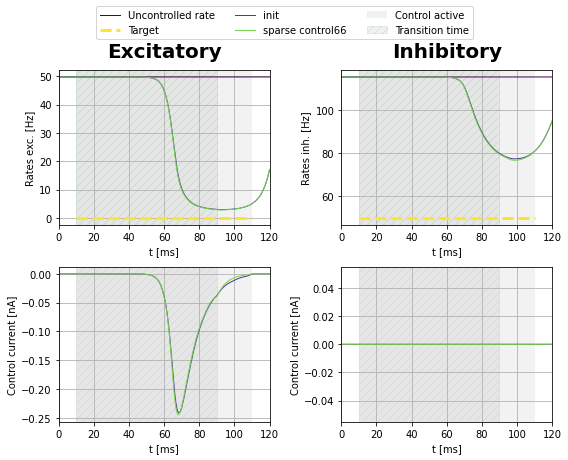

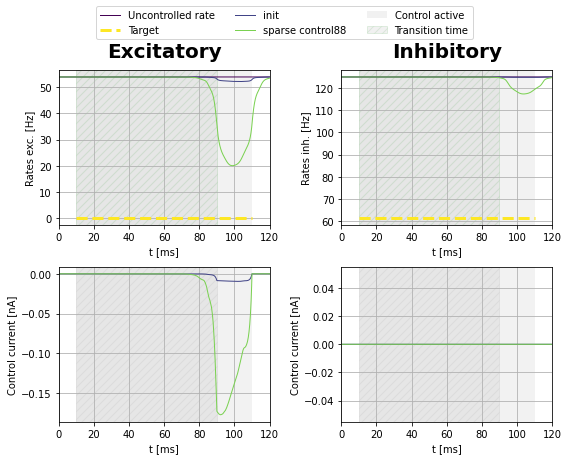

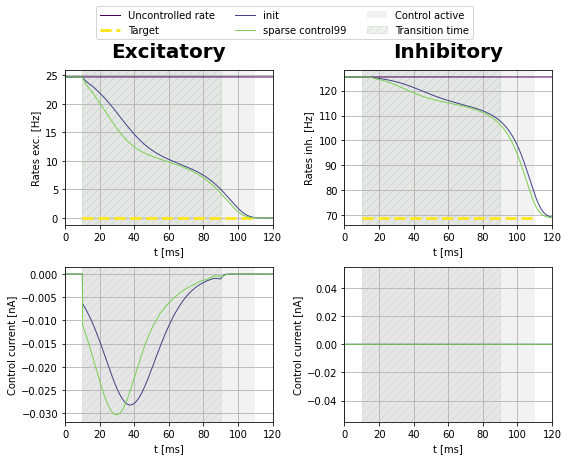

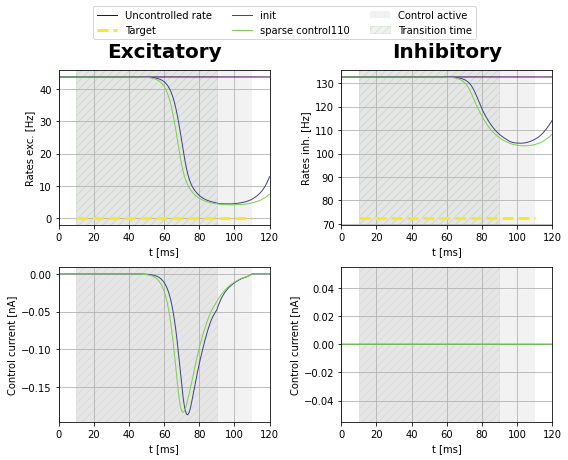

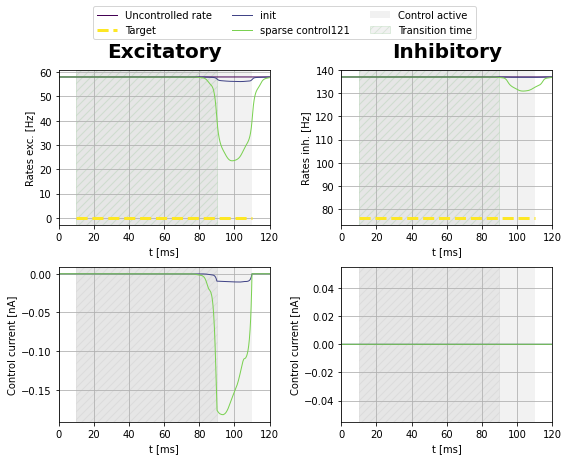

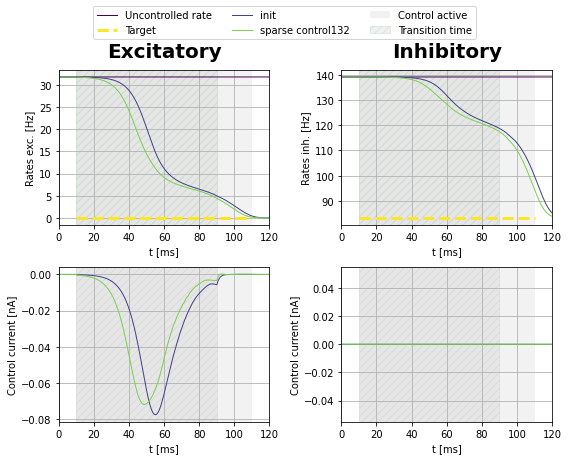

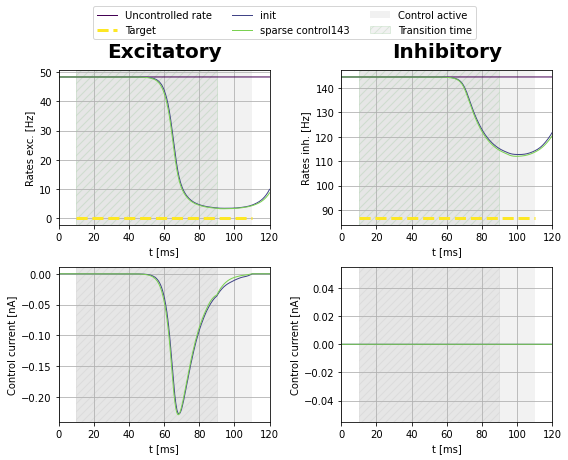

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  5743.906436689034
set cost params:  1.0 0.0 5743.906436689034
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13305.477054785457
Gradient descend method:  None
RUN  1 , total integrated cost =  13305.422577124702
RUN  2 , total integrated cost =  13305.422573756925
RUN  3 , total integrated cost =  13305.422573647578
RUN  4 , total integrated cost =  13305.422573647576


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  13305.422573647576
Control only changes marginally.
RUN  5 , total integrated cost =  13305.422573647576
Improved over  5  iterations in  0.9848911035805941  seconds by  0.0004094639948277745  percent.
Problem in initial value trasfer:  Vmean_exc -59.31239042283414 -59.32392495762551
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  5951.203964301155
set cost params:  1.0 0.0 5951.203964301155
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21556.396222685737
Gradient descend method:  None
RUN  1 , total integrated cost =  21556.34957857901
RUN  2 , total integrated cost =  21556.346200974283
RUN  3 , total integrated cost =  21556.345546828266
RUN  4 , total integrated cost =  21556.34526672765
RUN  5 , total integrated cost =  21556.345052220753
RUN  6 , total integrated cost =  21556.344954788965
RUN  7 , total integrated cost =  21556.34485339563
RUN  8 , total integrated cost =  21556.344670723993
R

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  28 , total integrated cost =  21553.375806273823
Improved over  28  iterations in  6.364674955606461  seconds by  0.014011694629800786  percent.
Problem in initial value trasfer:  Vmean_exc -57.643930272810344 -57.63168070712457
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  5990.211119826611
set cost params:  1.0 0.0 5990.211119826611
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21060.126485717097
Gradient descend method:  None
RUN  1 , total integrated cost =  21060.08451338971
RUN  2 , total integrated cost =  21060.08138490389
RUN  3 , total integrated cost =  21060.080883522034
RUN  4 , total integrated cost =  21060.080664303237
RUN  5 , total integrated cost =  21060.080593101142
RUN  6 , total integrated cost =  21060.080556774195
RUN  7 , total integrated cost =  21060.08053502676
RUN  8 , total integrated cost =  21060.08049735925
RUN  9 , total integrated cost =  21060.08049227263
RU

...

RUN  2 , total integrated cost =  33627.6745001496
RUN  3 , total integrated cost =  33627.6745001496
Control only changes marginally.
RUN  3 , total integrated cost =  33627.6745001496
Improved over  3  iterations in  0.5420174617320299  seconds by  8.000617413017608e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.703701734297816 -56.70367852778387
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
--------------- 100
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [False, False], [True, True], [True, True]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  4

ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  29121.521463988833
RUN  4 , total integrated cost =  29121.521463988833
Control only changes marginally.
RUN  4 , total integrated cost =  29121.521463988833
Improved over  4  iterations in  0.7641367837786674  seconds by  7.283647107669822e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.70410200167945 -56.70411059881808
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-------  121 0.5750000000000002 0.8250000000000005
no convergence
weight =  8712.488638552746
set cost params:  1.0 0.0 8712.488638552746
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33627.70545485763
Gradient descend method:  None
RUN  1 , total integrated cost =  33627.70543785583


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  33627.70543785579
RUN  3 , total integrated cost =  33627.70543785579
Control only changes marginally.
RUN  3 , total integrated cost =  33627.70543785579
Improved over  3  iterations in  0.5308797974139452  seconds by  5.055902363437781e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.703701386057865 -56.70367821089982
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
--------------- 101


In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [False, False], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  97.43870041204201
Gradient descend method:  None
RUN  1 , total integrated cost =  2.5338604888590948
RUN  2 , total integrated cost =  2.5336125355561396
RUN  3 , total integrated cost =  2.5315474690396584
RUN  4 , total integrated cost =  2.5313508367980164
RUN  5 , total integrated cost =  2.531346055213259
RUN  6 , total integrated cost =  2.5313455485420118
RUN  7 , total integrated cost =  2.531345464265061
RUN  8 , total integrated cost =  2.5313454633720758
RUN  9 , total integrated cost =  2.5313454633720753
RUN  10 , total integrated cost =  2.531345463372075
RUN  11 , total integrated cost =  2.531345463372073


ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  2.5313454633720727
RUN  13 , total integrated cost =  2.5313454633720727
Control only changes marginally.
RUN  13 , total integrated cost =  2.5313454633720727
Improved over  13  iterations in  0.6227573193609715  seconds by  97.40211491669358  percent.
Problem in initial value trasfer:  Vmean_exc -66.19697392379987 -66.19855583392223
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  141.94350564671382
Gradient descend method:  None
RUN  1 , total integrated cost =  4.009540540418202
RUN  2 , total integrated cost =  4.009533617710546
RUN  3 , total integrated cost =  4.009424466636741
RUN  4 , total integrated cost =  4.001809170649967
RUN  5 , total integrated cost =  3.999097977966405
RUN  6 , total integrated cost =  3.9990920334217215
RUN  7 , total integrated cost =  3.999091866341668
RUN  8 , total integrated cost =  3.999091863145591
RUN  9 , 

ERROR:root:Problem in initial value trasfer


RUN  14 , total integrated cost =  3.999091862971084
RUN  15 , total integrated cost =  3.999091862971084
Control only changes marginally.
RUN  15 , total integrated cost =  3.999091862971084
Improved over  15  iterations in  0.6713610514998436  seconds by  97.18261723581458  percent.
Problem in initial value trasfer:  Vmean_exc -65.58942184905098 -65.59154268926301
-------  33 0.5000000000000002 0.5250000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  144.02638366786604
Gradient descend method:  None
RUN  1 , total integrated cost =  3.909607423847121
RUN  2 , total integrated cost =  3.909606095182734
RUN  3 , total integrated cost =  3.909605852325603
RUN  4 , total integrated cost =  3.9096058523256025
RUN  5 , total integrated cost =  3.909605852325602


...

Control only changes marginally.
RUN  84 , total integrated cost =  5.941289849794396
Improved over  84  iterations in  3.2684488613158464  seconds by  99.98172055022441  percent.
Problem in initial value trasfer:  Vmean_exc -65.81270679100606 -65.82326180498609
-------  132 0.4500000000000001 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  61.186504328380664
Gradient descend method:  None
RUN  1 , total integrated cost =  1.6618126287555026
RUN  2 , total integrated cost =  1.6602734869911715
RUN  3 , total integrated cost =  1.6602656850893829


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  1.6602656850893822
RUN  5 , total integrated cost =  1.6602656850893815
RUN  6 , total integrated cost =  1.6602656850893815
Control only changes marginally.
RUN  6 , total integrated cost =  1.6602656850893815
Improved over  6  iterations in  0.36889155954122543  seconds by  97.28654920997131  percent.
Problem in initial value trasfer:  Vmean_exc -73.85920312771219 -73.89292658989051
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  123.32351122833738
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  4.115683564576501
RUN  2 , total integrated cost =  4.1156835645765
RUN  3 , total integrated cost =  4.1156835645765
Control only changes marginally.
RUN  3 , total integrated cost =  4.1156835645765
Improved over  3  iterations in  0.24274050816893578  seconds by  96.66269349324949  percent.
Problem in initial value trasfer:  Vmean_exc -69.35389361074557 -69.37494778606832


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.5313454633720727
Gradient descend method:  None
RUN  1 , total integrated cost =  2.5313454633720727
Control only changes marginally.
RUN  1 , total integrated cost =  2.5313454633720727
Improved over  1  iterations in  0.11286582238972187  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -66.19697392379987 -66.19855583392223
-------  22 0.5000000000000002 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.999091862971084
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3.999091862971084
Control only changes marginally.
RUN  1 , total integrated cost =  3.999091862971084
Improved over  1  iterations in  0.1133917048573494  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.58942184905098 -65.59154268926301
-------  33 0.5000000000000002 0.5250000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.909605852325602
Gradient descend method:  None
RUN  1 , total integrated cost =  3.909605852325602
Control only changes marginally.
RUN  1 , total integrated cost =  3.909605852325602
Improved over  1  iterations in  0.11225935257971287  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -67.14760688607554 -67.15717063631575
-------  44 0.47500000000000014 0.5750000000000003
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.051417288874241

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  0.7828039080002542
Control only changes marginally.
RUN  1 , total integrated cost =  0.7828039080002542
Improved over  1  iterations in  0.11312318779528141  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -75.15962357599236 -75.1945146053094
-------  110 0.5000000000000002 0.8000000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.523463618503659
Gradient descend method:  None
RUN  1 , total integrated cost =  3.523463618503659
Control only changes marginally.
RUN  1 , total integrated cost =  3.523463618503659
Improved over  1  iterations in  0.11162083968520164  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -70.12810917155588 -70.1532871290424
-------  121 0.5750000000000002 0.8250000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5.9412898497943

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5.941289849794396
Control only changes marginally.
RUN  1 , total integrated cost =  5.941289849794396
Improved over  1  iterations in  0.11485480517148972  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.81270679100606 -65.82326180498609
-------  132 0.4500000000000001 0.8750000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.6602656850893815
Gradient descend method:  None
RUN  1 , total integrated cost =  1.6602656850893815
Control only changes marginally.
RUN  1 , total integrated cost =  1.6602656850893815
Improved over  1  iterations in  0.1105234045535326  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.85920312771219 -73.89292658989051
-------  143 0.5250000000000001 0.9000000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4.11568356457

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  4.1156835645765
Control only changes marginally.
RUN  1 , total integrated cost =  4.1156835645765
Improved over  1  iterations in  0.1153562180697918  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -69.35389361074557 -69.37494778606832
--------------- 12
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  88 0.5500000000000003 0.7250000000000004
conve

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
